In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle # Để lưu model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Cấu hình hiển thị biểu đồ đẹp hơn
sns.set(style="whitegrid")

print("Đã nhập thư viện thành công!")

Đã nhập thư viện thành công!


In [16]:
# Đọc file CSV (Đảm bảo file này nằm cùng thư mục với notebook)
try:
    df = pd.read_csv('all_features.csv')
    print("--> Đã tải dữ liệu thành công!")
except FileNotFoundError:
    print("LỖI: Không tìm thấy file 'all_features.csv'. Hãy kiểm tra lại tên file hoặc vị trí.")

# Hiển thị 5 dòng đầu
display(df.head())

# Kiểm tra số lượng mỗi nhãn (Quan trọng!)
print("\nSố lượng ảnh cho mỗi trạng thái:")
print(df['label'].value_counts())

--> Đã tải dữ liệu thành công!


,x33,y33,z33,x160,y160,z160,x158,y158,z158,x133,...,x14,y14,z14,x17,y17,z17,x402,y402,z402,label
0,0.160780,0.411710,0.042929,0.203678,0.390692,-0.009656,0.275643,0.386124,-0.023770,0.354128,...,0.446182,0.788569,-0.037065,0.446081,0.838055,-0.039975,0.532084,0.784814,-0.015855,Awake
1,0.161037,0.410488,0.046431,0.203284,0.388986,-0.004320,0.272637,0.383408,-0.017862,0.347945,...,0.476729,0.798465,-0.036593,0.476329,0.846475,-0.048256,0.583475,0.785349,-0.014216,Awake
2,0.212923,0.406621,0.073979,0.250315,0.388496,0.026975,0.312710,0.380697,0.013937,0.383586,...,0.498139,0.770070,-0.075166,0.497922,0.823165,-0.082496,0.582611,0.769272,-0.056496,Awake
3,0.198193,0.414157,0.053684,0.234492,0.396596,0.006602,0.298729,0.390910,-0.006132,0.373270,...,0.521990,0.796581,-0.041619,0.524467,0.852740,-0.046481,0.624809,0.781539,-0.015114,Awake
4,0.192776,0.430409,0.055414,0.231176,0.412686,0.009090,0.297305,0.406079,-0.002739,0.372090,...,0.527581,0.793249,-0.048437,0.533684,0.844010,-0.057828,0.634601,0.776817,-0.020853,Awake



Số lượng ảnh cho mỗi trạng thái:
label
closed_eyes    912
yawn           886
Awake          561
Name: count, dtype: int64


C:\Users\Khanh\AppData\Local\Temp\ipykernel_8652\1202633263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')


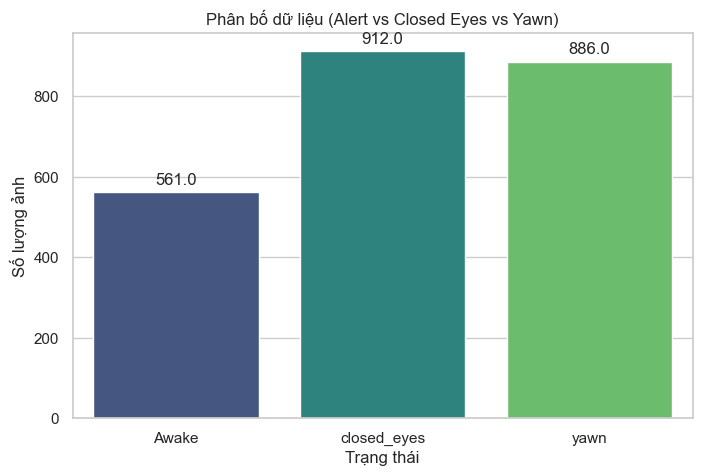

In [17]:
# Vẽ biểu đồ cột
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=df, palette='viridis')

# Thêm số lượng lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title('Phân bố dữ liệu (Alert vs Closed Eyes vs Yawn)')
plt.xlabel('Trạng thái')
plt.ylabel('Số lượng ảnh')
plt.show()

In [18]:
# Tách đặc trưng (X) và nhãn (y)
X = df.drop('label', axis=1) # Lấy tất cả cột trừ cột label
y = df['label']              # Chỉ lấy cột label

# Chia tách: 80% Train - 20% Test
# stratify=y: Đảm bảo tỉ lệ các nhãn ở tập Train và Test giống nhau
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Tổng số mẫu: {len(df)}")
print(f"- Dùng để dạy (Train): {X_train.shape[0]} mẫu")
print(f"- Dùng để thi (Test):  {X_test.shape[0]} mẫu")

Tổng số mẫu: 2359
- Dùng để dạy (Train): 1887 mẫu
- Dùng để thi (Test):  472 mẫu


In [19]:
# Khởi tạo mô hình Random Forest
model = RandomForestClassifier(
    n_estimators=100,  # Số lượng cây quyết định
    random_state=42,   # Giữ kết quả ổn định
    n_jobs=-1          # Dùng tất cả sức mạnh CPU để chạy nhanh
    class_weight='balanced'  # <--- THÊM DÒNG QUAN TRỌNG NÀY
)

print("Đang huấn luyện mô hình...")
model.fit(X_train, y_train) # Máy tính bắt đầu học tại dòng này
print("--> HUẤN LUYỆN HOÀN TẤT!")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3597129130.py, line 5)

ĐỘ CHÍNH XÁC TRÊN TẬP TEST: 98.09%
------------------------------------------------------------
              precision    recall  f1-score   support

       Awake       0.93      0.99      0.96       112
 closed_eyes       0.99      0.96      0.97       183
        yawn       1.00      1.00      1.00       177

    accuracy                           0.98       472
   macro avg       0.98      0.98      0.98       472
weighted avg       0.98      0.98      0.98       472



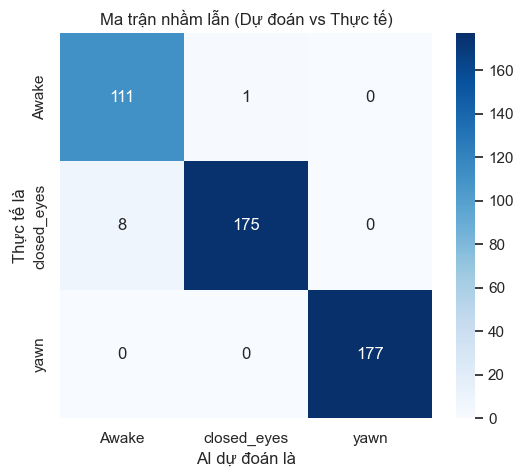

In [ ]:
# Dự đoán trên tập Test
y_pred = model.predict(X_test)

# Tính độ chính xác
accuracy = accuracy_score(y_test, y_pred)
print(f"ĐỘ CHÍNH XÁC TRÊN TẬP TEST: {accuracy*100:.2f}%")
print("-" * 60)

# Báo cáo chi tiết
print(classification_report(y_test, y_pred))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Ma trận nhầm lẫn (Dự đoán vs Thực tế)')
plt.ylabel('Thực tế là')
plt.xlabel('AI dự đoán là')
plt.show()

In [ ]:
filename = 'model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Đã lưu thành công model vào file: {filename}")
print("Bây giờ bạn có thể chuyển sang chạy file 4_predict_live.py!")

Đã lưu thành công model vào file: model.pkl
Bây giờ bạn có thể chuyển sang chạy file 4_predict_live.py!
